<a href="https://colab.research.google.com/github/nepslor/teaching/blob/main/CAS_BDML/L_05_serving.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# From Data to Deployment: A PM10 Forecasting Pipeline

This notebook walks through a **simplified end-to-end forecasting pipeline** applied to **air-quality data** from the canton of Ticino (Switzerland).

| Stage | Tool | What we do |
|:------|:-----|:-----------|
| 1. Data Retrieval | OASI REST API | Fetch PM10 and meteorological data for Bioggio |
| 2. Exploratory Analysis | `pandas` / `matplotlib` | Understand patterns, seasonality, meteo correlations |
| 3. Feature Engineering & Training | `scikit-learn` | Build and evaluate PM10 forecasting models |
| 4. Experiment Tracking | `MLflow` | Version experiments, parameters, metrics, and models |
| 5. Model Serving | `FastAPI` | Deploy the model as a REST API |

```
┌──────────┐    ┌──────────┐    ┌──────────┐    ┌──────────┐    ┌──────────┐
│   OASI   │───▶│   EDA    │───▶│  Model   │───▶│  MLflow  │───▶│ FastAPI  │
│ REST API │    │          │    │ Training │    │ Tracking │    │ Serving  │
└──────────┘    └──────────┘    └──────────┘    └──────────┘    └──────────┘
```

**Data source** — [OASI](https://www.oasi.ti.ch) (Osservatorio Ambientale della Svizzera Italiana) provides open environmental monitoring data via a public REST API.

> Inspired by the DataCamp course *Designing Forecasting Pipelines for Production*.

In [1]:
%pip install scikit-learn mlflow fastapi uvicorn httpx shap --quiet
# If using uv, run instead:  !uv pip install scikit-learn mlflow fastapi uvicorn httpx shap

/Users/lorenzo.nespoli/PycharmProjects/teaching/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
import requests
from io import StringIO
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import mlflow
import json
import os
import warnings

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 100

---
## 1. Data Retrieval from the OASI REST API

The [OASI REST API](http://www.oasi.ti.ch/web/dati/api.html) provides environmental monitoring data for Ticino. The key endpoints are:

| Endpoint | Purpose |
|:---------|:--------|
| `/web/rest/domain` | List available domains (air, meteo, noise, …) |
| `/web/rest/locations?domain=…&from=…&to=…` | List monitoring stations |
| `/web/rest/parameters?domain=…&location=…&from=…&to=…` | List available parameters at a station |
| `/web/rest/measure/csv?domain=…&resolution=…&parameter=…&location=…&from=…&to=…` | **Download data** as CSV |

We'll download **3 years** of data for the **Bioggio** station (location code `air_511 02 08`):

| Parameter | Domain | Unit | Resolution |
|:----------|:-------|:-----|:-----------|
| PM10 | air | µg/m³ | daily |
| T (temperature) | meteo | °C | daily |
| WS (wind speed) | meteo | m/s | daily |
| WDvect (wind direction) | meteo | grd | **sub-hourly** → daily via circular mean |
| RH (relative humidity) | meteo | % | daily |
| Prec (precipitation) | meteo | mm | daily |
| Gl (global radiation) | meteo | W/m² | daily |

In [2]:
OASI_BASE = "http://www.oasi.ti.ch/web/rest"
LOCATION  = "air_511 02 08"   # Bioggio
START     = "2023-01-01"
END       = "2025-12-31"


def fetch_oasi(domain, parameter, resolution="d",
               start=None, end=None):
    """Download one parameter from OASI and return it as a pandas Series.

    For sub-hourly data the API caps response size, so callers
    should chunk requests by year (see the WDvect download below).
    """
    r = requests.get(
        f"{OASI_BASE}/measure/csv",
        params={
            "domain": domain,
            "resolution": resolution,
            "parameter": parameter,
            "from": start or START,
            "to": end or END,
            "location": LOCATION,
        },
    )
    r.raise_for_status()

    # Keep only non-comment lines; parse the semicolon-separated CSV
    lines = [l for l in r.text.splitlines()
             if not l.startswith("#") and l.strip()]
    df = pd.read_csv(
        StringIO("\n".join(lines)),
        sep=";", usecols=[0, 1],
        names=["datetime", parameter], header=0,
    )
    df["datetime"] = pd.to_datetime(df["datetime"],
                                    format="%d.%m.%Y %H:%M:%S")
    df = df.set_index("datetime")
    df[parameter] = pd.to_numeric(df[parameter], errors="coerce")
    return df[parameter]

In [3]:
# ── Download daily parameters ────────────────────────────────────────────
daily_params = {
    "air":   ["PM10"],
    "meteo": ["T", "WS", "RH", "Prec", "Gl"],
}

series = {}
for domain, params in daily_params.items():
    for p in params:
        series[p] = fetch_oasi(domain, p, resolution="d")
        print(f"  {p:6s}  ({domain:5s}, daily)  → {len(series[p]):>5d} values")

# ── Wind direction: only available sub-hourly → aggregate to daily ───────
# The API caps sub-hourly responses, so we download year-by-year.
print("\n  Downloading sub-hourly WDvect (year by year)...")
wd_chunks = []
for year in range(int(START[:4]), int(END[:4]) + 1):
    chunk = fetch_oasi("meteo", "WDvect", resolution="h",
                       start=f"{year}-01-01", end=f"{year}-12-31")
    wd_chunks.append(chunk)
    print(f"    {year}: {len(chunk):>6d} records")
wd_raw = pd.concat(wd_chunks)
print(f"  WDvect (meteo, sub-hourly) → {len(wd_raw):>6d} records total")


def circular_mean(angles_deg):
    """Mean direction from a set of angles in degrees (vector average)."""
    rad = np.deg2rad(angles_deg.dropna())
    if len(rad) == 0:
        return np.nan
    return np.rad2deg(np.arctan2(np.sin(rad).mean(),
                                 np.cos(rad).mean())) % 360


wd_daily = wd_raw.resample("D").apply(circular_mean)
# Align timestamp with the other daily series (noon)
wd_daily.index = wd_daily.index + pd.Timedelta(hours=12)
wd_daily.name = "WDvect"
series["WDvect"] = wd_daily
print(f"  WDvect (daily, vector-avg) → {len(wd_daily):>6d} values")

  PM10    (air  , daily)  →  1096 values
  T       (meteo, daily)  →  1096 values
  WS      (meteo, daily)  →  1096 values
  RH      (meteo, daily)  →  1096 values
  Prec    (meteo, daily)  →  1096 values
  Gl      (meteo, daily)  →  1096 values

    2023:  52560 records
    2024:  52704 records
    2025:  52560 records
  WDvect (meteo, sub-hourly) → 157824 records total
  WDvect (daily, vector-avg) →   1096 values


In [4]:
# ── Merge into a single DataFrame ─────────────────────────────────────────
df = pd.concat(series.values(), axis=1)
df.index.name = "date"

print(f"Raw dataset : {df.shape[0]} days × {df.shape[1]} columns")
print(f"\nMissing values:\n{df.isna().sum()}")

df = df.dropna()
print(f"\nAfter dropping NAs: {df.shape[0]} days")
df.head(10)

Raw dataset : 1096 days × 7 columns

Missing values:
PM10       3
T          0
WS         0
RH         0
Prec       0
Gl        19
WDvect     0
dtype: int64

After dropping NAs: 1077 days


,PM10,T,WS,RH,Prec,Gl,WDvect
date,,,,,,,
2023-01-01 12:00:00,24.0,9.0,0.7,96.8,0.8,23.8,99.661442
2023-01-02 12:00:00,29.0,9.6,0.6,99.5,1.6,13.8,166.924773
2023-01-03 12:00:00,16.0,9.5,0.6,99.1,6.9,12.7,156.199670
2023-01-04 12:00:00,12.0,6.1,0.8,94.2,0.0,59.8,38.051105
2023-01-05 12:00:00,14.0,6.1,0.8,91.0,0.0,55.5,21.994408
2023-01-06 12:00:00,21.0,4.0,1.1,97.6,0.0,19.5,21.719556
2023-01-07 12:00:00,24.0,4.3,1.2,94.1,0.0,42.2,43.376207
2023-01-08 12:00:00,29.0,5.7,0.7,98.9,13.7,10.8,31.913103
2023-01-09 12:00:00,7.0,6.7,1.1,78.3,0.1,77.3,200.177483


In [5]:
df.describe().round(2)

,PM10,T,WS,RH,Prec,Gl,WDvect
count,1077.00,1077.00,1077.00,1077.00,1077.00,1077.00,1077.00
mean,17.51,13.75,1.34,77.12,4.60,154.47,99.83
std,10.62,7.47,0.67,16.22,12.15,100.21,74.78
min,1.00,-1.30,0.60,19.50,0.00,6.80,0.11
25%,10.00,7.30,0.90,68.30,0.00,69.90,37.35
50%,15.00,13.40,1.20,78.70,0.00,126.20,86.90
75%,23.00,20.10,1.40,89.90,1.90,247.30,146.21
max,65.00,28.70,5.60,100.30,127.20,361.60,359.74


---
## 2. Exploratory Data Analysis

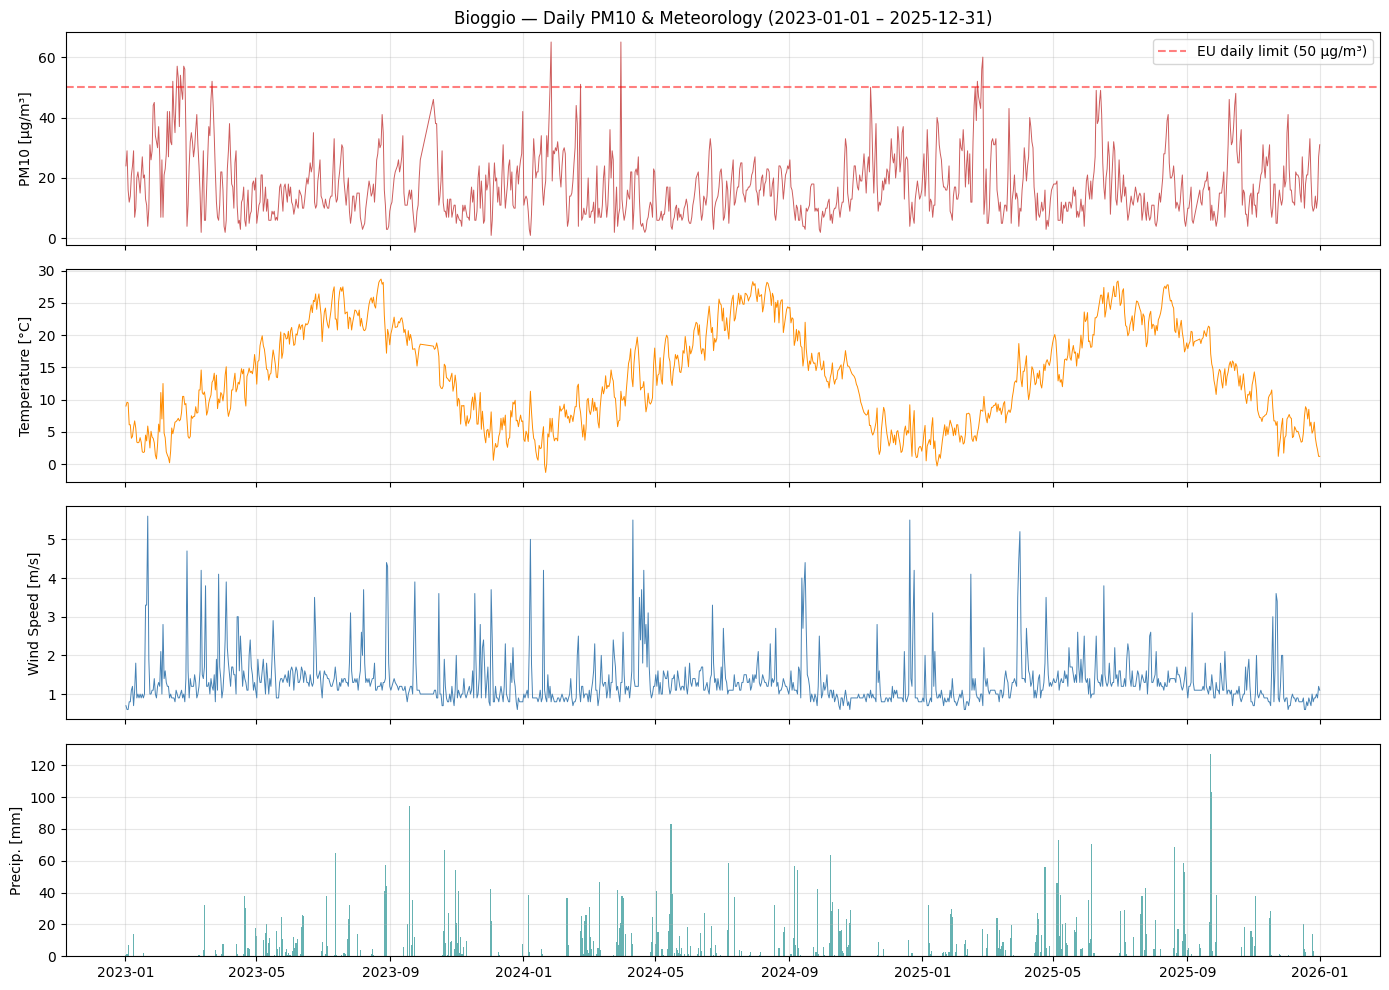

In [6]:
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

axes[0].plot(df.index, df["PM10"], linewidth=0.7, color="indianred")
axes[0].axhline(50, color="red", linestyle="--", alpha=0.5, label="EU daily limit (50 µg/m³)")
axes[0].set_ylabel("PM10 [µg/m³]")
axes[0].legend(loc="upper right")
axes[0].set_title(f"Bioggio — Daily PM10 & Meteorology ({START} – {END})")

axes[1].plot(df.index, df["T"], linewidth=0.7, color="darkorange")
axes[1].set_ylabel("Temperature [°C]")

axes[2].plot(df.index, df["WS"], linewidth=0.7, color="steelblue")
axes[2].set_ylabel("Wind Speed [m/s]")

axes[3].bar(df.index, df["Prec"], width=1, alpha=0.6, color="teal")
axes[3].set_ylabel("Precip. [mm]")

for ax in axes:
    ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

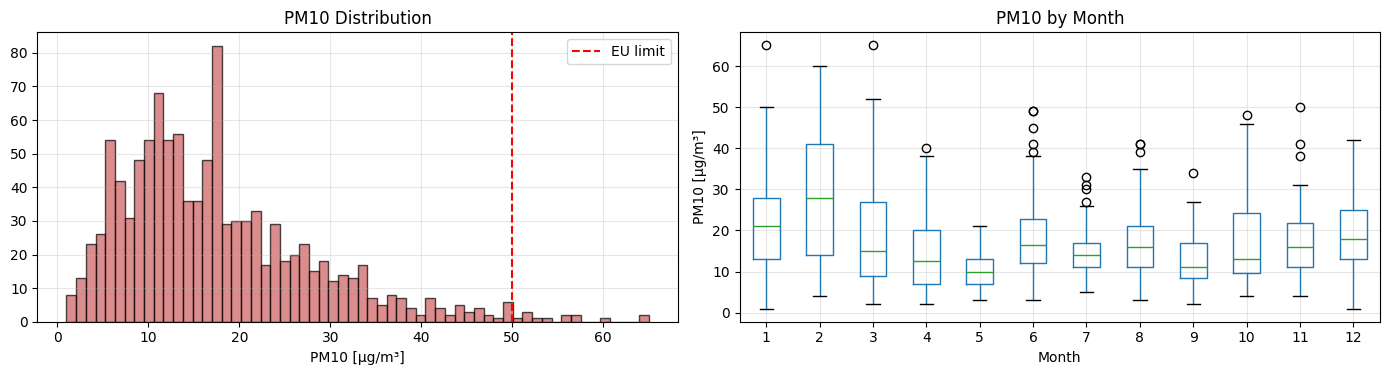

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df["PM10"], bins=60, edgecolor="black", alpha=0.7, color="indianred")
axes[0].axvline(50, color="red", linestyle="--", label="EU limit")
axes[0].set_xlabel("PM10 [µg/m³]")
axes[0].set_title("PM10 Distribution")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Monthly boxplot
df["month"] = df.index.month
df.boxplot(column="PM10", by="month", ax=axes[1])
axes[1].set_title("PM10 by Month")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("PM10 [µg/m³]")
plt.suptitle("")
axes[1].grid(True, alpha=0.3)

df.drop(columns="month", inplace=True)
fig.tight_layout()
plt.show()

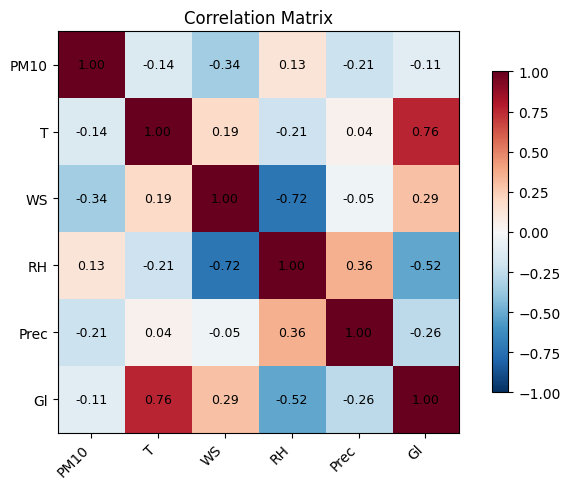

In [8]:
# Correlation between PM10 and meteorological variables
corr_cols = ["PM10", "T", "WS", "RH", "Prec", "Gl"]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha="right")
ax.set_yticklabels(corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}",
                ha="center", va="center", fontsize=9)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Correlation Matrix")
fig.tight_layout()
plt.show()

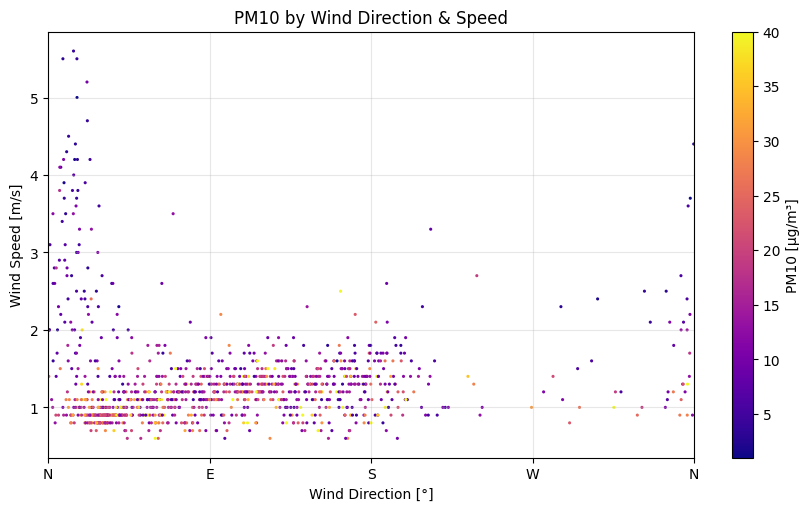

In [9]:
# Wind rose: PM10 concentration by wind direction and speed
fig, ax = plt.subplots(figsize=(8, 5), layout='constrained')
sc = ax.scatter(df["WDvect"], df["WS"], c=df["PM10"],
                cmap="plasma", alpha=1, s=5, edgecolors="none", vmax=40)
ax.set_xlabel("Wind Direction [°]")
ax.set_ylabel("Wind Speed [m/s]")
ax.set_xlim(0, 360)
ax.set_xticks([0, 90, 180, 270, 360])
ax.set_xticklabels(["N", "E", "S", "W", "N"])
ax.set_title("PM10 by Wind Direction & Speed")
fig.colorbar(sc, ax=ax, label="PM10 [µg/m³]")
ax.grid(True, alpha=0.3)
plt.show()

---
## 3. Feature Engineering & Model Training

We frame the problem as **1-day-ahead regression**: predict tomorrow's daily PM10 using features available today.

| Feature group | Features | Rationale |
|:-------------|:---------|:----------|
| PM10 lags | lag 1 … 14 d | Persistence / autoregressive signal |
| PM10 rolling stats | mean & std over 3, 7, 14 d | Trend and volatility |
| Same-day meteo | T, WS, RH, Prec, Gl | Weather drives air quality (proxy for NWP forecast) |
| Wind direction | sin(WD), cos(WD) | Circular encoding of wind bearing |
| Calendar | day-of-week, month (sin / cos) | Weekly & seasonal patterns |

> **Note** — In a production system, the "same-day" meteorological features would come from a numerical weather prediction (NWP) forecast issued the day before.  Here we use observed meteo as a proxy.

In [10]:
def create_features(df):
    """Build the feature matrix for PM10 next-day forecasting."""
    feat = pd.DataFrame(index=df.index)

    # PM10 lags
    for lag in [1, 2, 3, 7, 14]:
        feat[f"PM10_lag{lag}"] = df["PM10"].shift(lag)

    # PM10 rolling statistics (on shifted series to avoid look-ahead)
    shifted = df["PM10"].shift(1)
    for w in [3, 7, 14]:
        feat[f"PM10_rmean{w}"] = shifted.rolling(w).mean()
        feat[f"PM10_rstd{w}"]  = shifted.rolling(w).std()

    # Same-day meteorological observations (proxy for weather forecast)
    for col in ["T", "WS", "RH", "Prec", "Gl"]:
        feat[col] = df[col]

    # Wind direction → sin / cos encoding
    feat["WD_sin"] = np.sin(np.deg2rad(df["WDvect"]))
    feat["WD_cos"] = np.cos(np.deg2rad(df["WDvect"]))

    # Calendar features
    feat["dow"]       = df.index.dayofweek
    feat["month_sin"] = np.sin(2 * np.pi * df.index.month / 12)
    feat["month_cos"] = np.cos(2 * np.pi * df.index.month / 12)

    # Target
    feat["target"] = df["PM10"]

    return feat.dropna()


features = create_features(df)
FEATURE_COLS = [c for c in features.columns if c != "target"]

print(f"Feature matrix: {features.shape[0]} samples × {len(FEATURE_COLS)} features")
features.head()

Feature matrix: 1063 samples × 21 features


,PM10_lag1,PM10_lag2,PM10_lag3,PM10_lag7,PM10_lag14,PM10_rmean3,PM10_rstd3,PM10_rmean7,PM10_rstd7,PM10_rmean14,...,WS,RH,Prec,Gl,WD_sin,WD_cos,dow,month_sin,month_cos,target
date,,,,,,,,,,,,,,,,,,,,,
2023-01-15 12:00:00,15.0,19.0,22.0,29.0,24.0,18.666667,3.511885,17.428571,7.457818,18.714286,...,0.9,85.9,0.0,15.3,0.074996,0.997184,6,0.5,0.866025,21.0
2023-01-16 12:00:00,21.0,15.0,19.0,7.0,29.0,18.333333,3.055050,16.285714,5.822780,18.500000,...,1.0,97.6,0.4,20.3,0.538453,0.842656,0,0.5,0.866025,27.0
2023-01-17 12:00:00,27.0,21.0,15.0,10.0,16.0,21.000000,6.000000,19.142857,5.398412,18.357143,...,0.9,99.7,1.9,15.8,0.434983,0.900438,1,0.5,0.866025,20.0
2023-01-18 12:00:00,20.0,27.0,21.0,20.0,12.0,22.666667,3.785939,20.571429,3.598942,18.642857,...,1.0,88.3,0.0,87.1,0.686868,0.726782,2,0.5,0.866025,21.0
2023-01-19 12:00:00,21.0,20.0,27.0,22.0,14.0,22.666667,3.785939,20.714286,3.592320,19.285714,...,3.3,39.0,0.0,27.7,0.408315,0.912841,3,0.5,0.866025,13.0


Train:       401 days  (2023-01-15 → 2024-03-05)
Calibration: 100 days  (2024-03-06 → 2024-06-13)
Embargo:     30 days  (2024-06-14 → 2024-07-13)
Test:        532 days  (2024-07-14 → 2025-12-31)


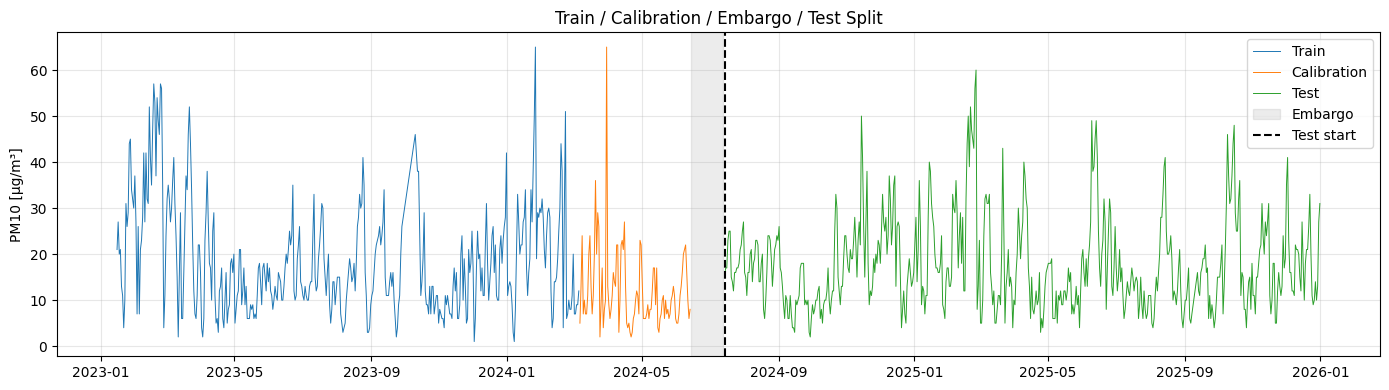

In [11]:
# Time-based split with explicit calibration and embargo periods
# Keep the last 50% for test, reserve a calibration block before test,
# and leave a 1-month embargo gap between calibration and test.
test_start_idx = int(len(features) * 0.5)
test_start_date = features.index[test_start_idx]
embargo_days = 30

test_block = features.iloc[test_start_idx:]
pre_test_block = features.iloc[:test_start_idx]

embargo_start_date = test_start_date - pd.Timedelta(days=embargo_days)
pre_embargo_block = pre_test_block.loc[pre_test_block.index < embargo_start_date]
embargo_block = features.loc[
    (features.index >= embargo_start_date) & (features.index < test_start_date)
]

cal_size = max(30, int(len(pre_embargo_block) * 0.2))
cal_size = min(cal_size, len(pre_embargo_block) - 1)

train_block = pre_embargo_block.iloc[:-cal_size]
cal_block = pre_embargo_block.iloc[-cal_size:]

X_train = train_block[FEATURE_COLS]
y_train = train_block["target"]
X_cal = cal_block[FEATURE_COLS]
y_cal = cal_block["target"]
X_test = test_block[FEATURE_COLS]
y_test = test_block["target"]

print(f"Train:       {len(X_train)} days  ({X_train.index[0].date()} → {X_train.index[-1].date()})")
print(f"Calibration: {len(X_cal)} days  ({X_cal.index[0].date()} → {X_cal.index[-1].date()})")
if len(embargo_block) > 0:
    print(
        f"Embargo:     {len(embargo_block)} days  "
        f"({embargo_block.index[0].date()} → {embargo_block.index[-1].date()})"
    )
else:
    print("Embargo:     0 days")
print(f"Test:        {len(X_test)} days  ({X_test.index[0].date()} → {X_test.index[-1].date()})")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(y_train.index, y_train, label="Train", linewidth=0.7)
ax.plot(y_cal.index, y_cal, label="Calibration", linewidth=0.7)
ax.plot(y_test.index, y_test, label="Test", linewidth=0.7)
if len(embargo_block) > 0:
    ax.axvspan(
        embargo_block.index[0],
        embargo_block.index[-1],
        color="gray",
        alpha=0.15,
        label="Embargo",
    )
ax.axvline(test_start_date, color="black", linestyle="--", label="Test start")
ax.set_title("Train / Calibration / Embargo / Test Split")
ax.set_ylabel("PM10 [µg/m³]")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

In [12]:
# Naive baseline: "tomorrow's PM10 = today's PM10" (persistence)
naive_preds = X_test["PM10_lag1"]
naive_mae  = mean_absolute_error(y_test, naive_preds)
naive_rmse = np.sqrt(mean_squared_error(y_test, naive_preds))

print(f"Naive baseline (persistence)")
print(f"  MAE  : {naive_mae:.2f} µg/m³")
print(f"  RMSE : {naive_rmse:.2f} µg/m³")

Naive baseline (persistence)
  MAE  : 5.10 µg/m³
  RMSE : 7.17 µg/m³


---
## 4. Experiment Tracking with MLflow

[MLflow](https://mlflow.org/) is an open-source platform for managing the ML lifecycle:

- **Tracking** — log parameters, metrics and artifacts for every experiment run
- **Models** — package models in a standard format, independent of the training library
- **Registry** — version and stage models (e.g. *staging → production*)

We will:
1. Train several models with different hyper-parameters
2. Log each run to MLflow
3. Compare runs and pick the best model
4. Register it in the Model Registry for serving

In [13]:
EXPERIMENT_NAME = "pm10_forecasting"

# Clean up previous runs so re-execution doesn't accumulate duplicates
import shutil, pathlib
for artifact in ["mlflow.db", "mlruns", "mlartifacts"]:
    p = pathlib.Path(artifact)
    if p.is_file():
        p.unlink()
    elif p.is_dir():
        shutil.rmtree(p)

mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment(EXPERIMENT_NAME)

print(f"Tracking URI : {mlflow.get_tracking_uri()}")
print(f"Experiment   : {EXPERIMENT_NAME}")

2026/05/11 11:44:56 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/11 11:44:56 INFO mlflow.store.db.utils: Updating database tables
2026/05/11 11:44:56 INFO mlflow.tracking.fluent: Experiment with name 'pm10_forecasting' does not exist. Creating a new experiment.


Tracking URI : sqlite:///mlflow.db
Experiment   : pm10_forecasting


### CRPS and Reliability metrics



In [14]:
q_vect = np.arange(11) / 10


def create_pdf(y_cal, y_hat_cal, q_vect=q_vect):
    err = y_cal - y_hat_cal
    q_errs = np.quantile(err, q_vect, axis=0).T
    return q_errs


def quantile_score(q, y, q_vect=q_vect):
    qs = {}
    for i, tau in enumerate(q_vect):
        err_tau = q[:, :, i] - y
        I = (err_tau > 0).astype(int)
        qs[tau] = np.mean((I - tau) * err_tau)
    return qs


def reliability(q, y, q_vect=q_vect):
    res = {}
    for i, tau in enumerate(q_vect):
        res[tau] = np.mean(y < q[:, :, i])
    return res


# Splits are defined in the previous cell: X_train, X_cal, X_test

model_configs = [
    {"name": "ridge_a1", "model": Ridge(alpha=1.0)},
    {"name": "ridge_a10", "model": Ridge(alpha=10.0)},
    {"name": "lasso_a01", "model": Lasso(alpha=0.1)},
    {
        "name": "lgb_100_d3",
        "model": LGBMRegressor(
            n_estimators=100,
            max_depth=3,
            learning_rate=0.01,
            verbosity=-1,
        ),
    },
    {
        "name": "lgb_200_d200",
        "model": LGBMRegressor(
            n_estimators=200, max_depth=200, learning_rate=0.01
        ),
    },
    {
        "name": "rf_200_d10",
        "model": RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42),
    },
]

for cfg in model_configs:
    with mlflow.start_run(run_name=cfg["name"]) as run:
        m = cfg["model"]
        m.fit(X_train, y_train)

        y_hat_cal = m.predict(X_cal)
        preds = m.predict(X_test)

        # Build probabilistic forecasts from empirical quantiles of calibration errors
        q_errs = create_pdf(
            y_cal.values.reshape(-1, 1),
            y_hat_cal.reshape(-1, 1),
            q_vect=q_vect,
        )
        q_pred = np.expand_dims(preds, (1, 2)) + np.expand_dims(q_errs, 0)
        y_eval = y_test.values.reshape(-1, 1)

        qs = quantile_score(q_pred, y_eval, q_vect=q_vect)
        rel = reliability(q_pred, y_eval, q_vect=q_vect)
        crps = float(np.mean(list(qs.values())))
        mean_abs_rel_dev = float(np.mean([abs(rel[tau] - tau) for tau in q_vect]))

        mae = mean_absolute_error(y_test, preds)
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        r2 = r2_score(y_test, preds)

        mlflow.log_param("location", LOCATION)
        mlflow.log_param("target", "PM10")
        mlflow.log_param("n_train", X_train.shape[0])
        mlflow.log_param("n_cal", X_cal.shape[0])
        mlflow.log_param("n_test", X_test.shape[0])
        mlflow.log_param("n_features", X_train.shape[1])
        mlflow.log_param("n_quantiles", len(q_vect))
        mlflow.log_params({k: str(v) for k, v in m.get_params().items()})

        all_metrics = {
            "mae": mae,
            "rmse": rmse,
            "r2": r2,
            "naive_mae": naive_mae,
            "crps": crps,
            "mean_abs_rel_dev": mean_abs_rel_dev,
        }
        all_metrics.update({f"qs_p{int(tau * 100):02d}": float(v) for tau, v in qs.items()})
        all_metrics.update({f"rel_p{int(tau * 100):02d}": float(v) for tau, v in rel.items()})
        mlflow.log_metrics(all_metrics)

        mlflow.sklearn.log_model(
            m,
            artifact_path="model",
            input_example=X_test.iloc[:1],
        )

        print(
            f"  {cfg['name']:15s} | MAE={mae:6.2f} | RMSE={rmse:6.2f} | "
            f"R²={r2:.4f} | CRPS={crps:.4f} | "
            f"Mean abs reliability deviation={mean_abs_rel_dev:.4f}"
        )

print(f"\nAll runs logged. Naive baseline MAE = {naive_mae:.2f} µg/m³")

2026/05/11 11:44:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/11 11:44:57 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/11 11:45:00 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/11 11:45:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/11 11:45:00 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, wh

  ridge_a1        | MAE=  4.77 | RMSE=  6.44 | R²=0.5812 | CRPS=1.5451 | Mean abs reliability deviation=0.0177


2026/05/11 11:45:01 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/11 11:45:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/11 11:45:01 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  ridge_a10       | MAE=  4.71 | RMSE=  6.38 | R²=0.5890 | CRPS=1.5224 | Mean abs reliability deviation=0.0128


2026/05/11 11:45:03 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/11 11:45:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/11 11:45:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


...

  lgb_100_d3      | MAE=  5.32 | RMSE=  6.96 | R²=0.5107 | CRPS=1.9038 | Mean abs reliability deviation=0.1391


2026/05/11 11:45:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/11 11:45:05 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/11 11:45:07 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


  lgb_200_d200    | MAE=  4.46 | RMSE=  6.12 | R²=0.6223 | CRPS=1.5381 | Mean abs reliability deviation=0.1034


2026/05/11 11:45:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/11 11:45:07 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/11 11:45:09 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


  rf_200_d10      | MAE=  4.37 | RMSE=  6.07 | R²=0.6279 | CRPS=1.4793 | Mean abs reliability deviation=0.0709

All runs logged. Naive baseline MAE = 5.10 µg/m³


In [15]:
experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
runs_df = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    order_by=["metrics.crps ASC"],
)

cols = [
    "tags.mlflow.runName",
    "metrics.mae",
    "metrics.rmse",
    "metrics.r2",
    "metrics.crps",
    "metrics.rel_p50",
]
runs_df[cols].head(13)

,tags.mlflow.runName,metrics.mae,metrics.rmse,metrics.r2,metrics.crps,metrics.rel_p50
0,rf_200_d10,4.371969,6.070857,0.627899,1.479313,0.343985
1,lasso_a01,4.668342,6.349608,0.592943,1.510800,0.479323
2,ridge_a10,4.707284,6.380027,0.589034,1.522394,0.481203
3,lgb_200_d200,4.462404,6.116027,0.622341,1.538061,0.317669
4,ridge_a1,4.767605,6.440230,0.581241,1.545063,0.503759
5,lgb_100_d3,5.322034,6.961561,0.510701,1.903765,0.287594


In [16]:
best_run = runs_df.iloc[0]
best_run_id = best_run.run_id
best_run_name = best_run["tags.mlflow.runName"]

print(f"Best model: {best_run_name}")
print(f"  run_id : {best_run_id}")
print(f"  MAE    : {best_run['metrics.mae']:.2f} µg/m³")
print(f"  RMSE   : {best_run['metrics.rmse']:.2f} µg/m³")
print(f"  R²     : {best_run['metrics.r2']:.4f}")
print(f"  CRPS   : {best_run['metrics.crps']:.4f}")

# Register in the MLflow Model Registry
MODEL_NAME = "pm10_forecasting_model"
reg = mlflow.register_model(f"runs:/{best_run_id}/model", MODEL_NAME)
print(f"\nRegistered as '{MODEL_NAME}' version {reg.version}")

Successfully registered model 'pm10_forecasting_model'.
2026/05/11 11:45:09 WARNING mlflow.tracking._model_registry.fluent: Run with id 8e3ccb35c16243e28e8556304c7ac2c0 has no artifacts at artifact path 'model', registering model based on models:/m-cf91121fdca34f979a3c36bc454a1106 instead


Best model: rf_200_d10
  run_id : 8e3ccb35c16243e28e8556304c7ac2c0
  MAE    : 4.37 µg/m³
  RMSE   : 6.07 µg/m³
  R²     : 0.6279
  CRPS   : 1.4793

Registered as 'pm10_forecasting_model' version 1


Created version '1' of model 'pm10_forecasting_model'.


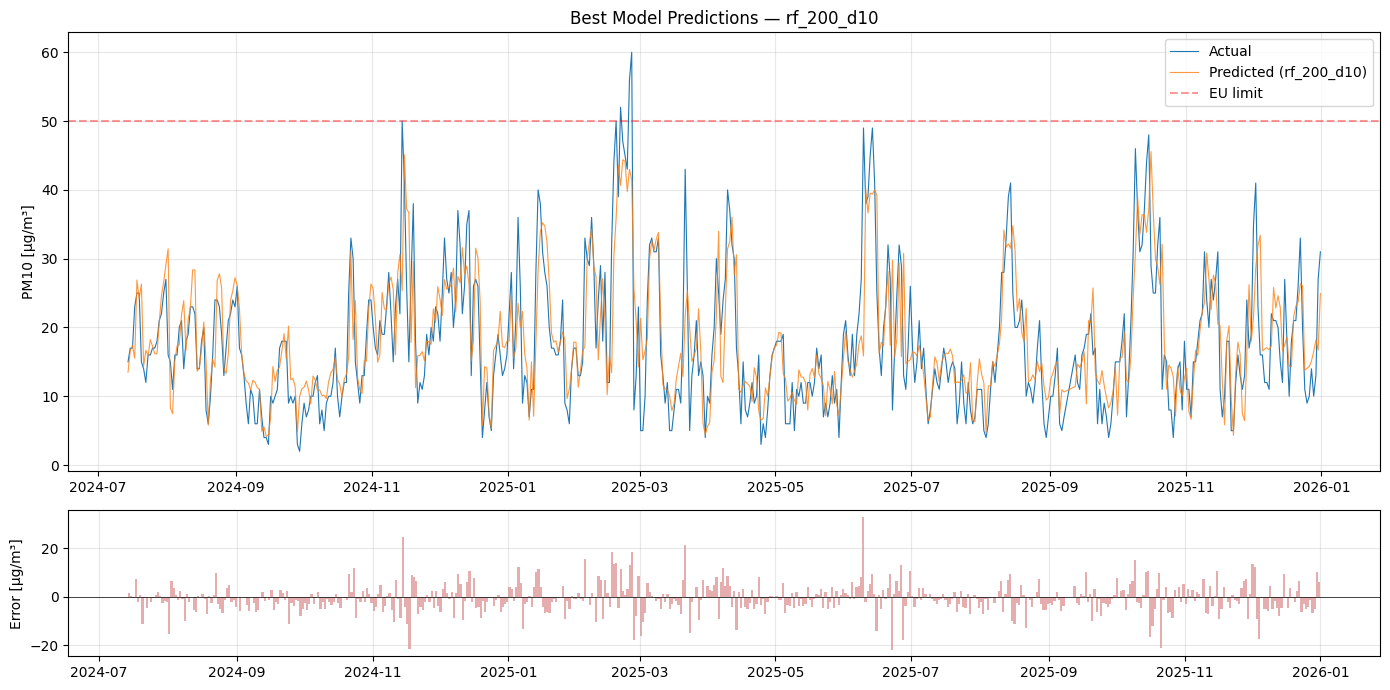

In [17]:
best_model = mlflow.sklearn.load_model(f"runs:/{best_run_id}/model")
best_preds = best_model.predict(X_test)

fig, axes = plt.subplots(2, 1, figsize=(14, 7),
                         gridspec_kw={"height_ratios": [3, 1]})

axes[0].plot(y_test.index, y_test.values, label="Actual", linewidth=0.8)
axes[0].plot(y_test.index, best_preds, label=f"Predicted ({best_run_name})",
             linewidth=0.8, alpha=0.8)
axes[0].axhline(50, color="red", linestyle="--", alpha=0.4, label="EU limit")
axes[0].set_title(f"Best Model Predictions — {best_run_name}")
axes[0].set_ylabel("PM10 [µg/m³]")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

errors = y_test.values - best_preds
axes[1].bar(y_test.index, errors, width=1, alpha=0.5, color="indianred")
axes[1].set_ylabel("Error [µg/m³]")
axes[1].axhline(0, color="black", linewidth=0.5)
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

> **Tip — MLflow UI**: Explore all experiments interactively by running in a terminal:
> ```bash
> mlflow ui --backend-store-uri sqlite:///mlflow.db
> ```
> then open http://localhost:5000.

(-0.2, 1.0)

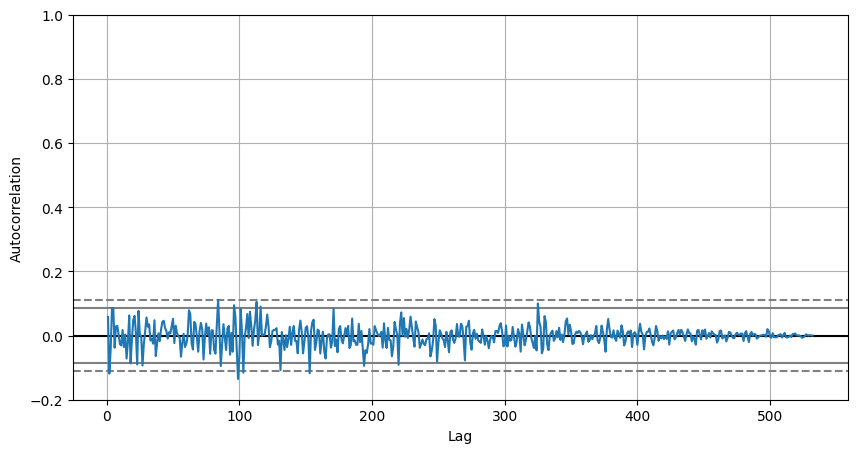

In [18]:
# plot ACF of residuals
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
pd.plotting.autocorrelation_plot(pd.Series(errors), ax=ax)
ax.set_ylim(-0.2, 1)

### Feature Importance & Interaction Analysis with SHAP

The correlation matrix above only captures *linear, pairwise* relationships. The wind-rose plot, however, revealed a clear **non-linear interaction**: northerly winds tend to be stronger and are associated with low PM10 (Föhn-like ventilation), while calm winds from other directions trap pollutants.

[SHAP](https://shap.readthedocs.io/) (SHapley Additive exPlanations) assigns each feature an importance value *for every individual prediction*, based on cooperative game theory. This lets us:
1. Rank features by global importance
2. Visualise **how** each feature drives the prediction (not just *how much*)
3. Capture **interaction effects** that simple correlation misses

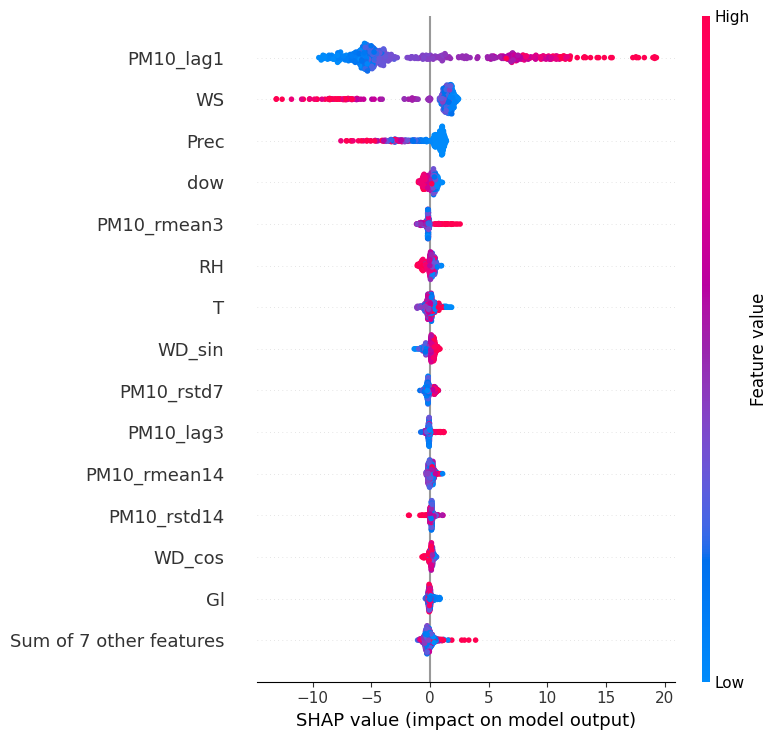

In [19]:
import shap

explainer = shap.TreeExplainer(best_model)
shap_values = explainer(X_test)

# Beeswarm: shows direction & magnitude of each feature's effect
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.tight_layout()
plt.show()

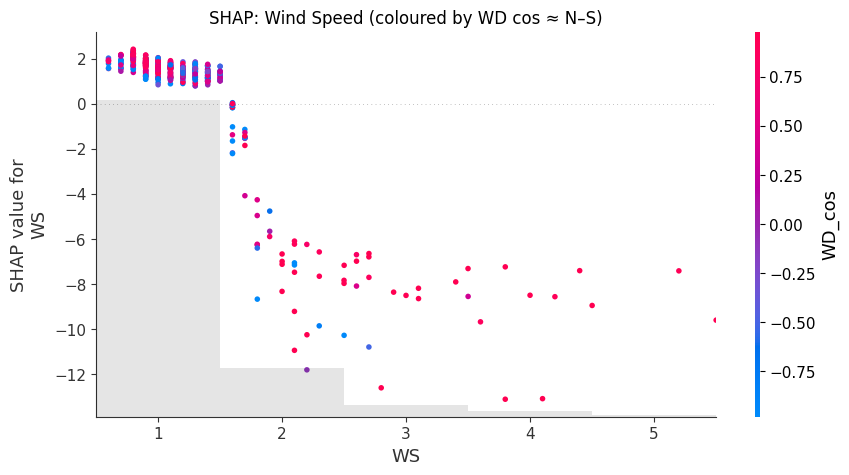

In [20]:
# ── Wind speed × wind direction interaction ──────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

# WS dependence coloured by WD_cos (cos component ≈ N-S axis: cos=1→N, cos=-1→S)
shap.plots.scatter(shap_values[:, "WS"], color=shap_values[:, "WD_cos"],
                   ax=ax, show=False)
ax.set_title("SHAP: Wind Speed (coloured by WD cos ≈ N–S)")
plt.show()

**Reading the plots above:**

- The **SHAP bar plot** ranks features by average impact on predictions. PM10 lags dominate (persistence), but meteorological features — especially wind speed and temperature — contribute meaningfully.
- The **beeswarm** shows *direction*: high wind speed (red dots) consistently pushes predictions *down* (negative SHAP), confirming that strong wind disperses PM10.
- The **SHAP dependence plots** reveal the interaction: the PM10-reducing effect of wind speed is *strongest* when the wind blows from the north (high `WD_cos`). This north-wind ventilation pattern is invisible to a plain correlation matrix, but confirms the scatter plot we did on the raw data: **our forecasting model correctly captures this phenomenon**.



---
## 5. Model Serving with FastAPI

[FastAPI](https://fastapi.tiangolo.com/) is a modern Python web framework for building APIs:

- Automatic **request validation** via Pydantic models
- Auto-generated **interactive docs** (Swagger UI at `/docs`)
- **Async** support and high performance

Our API will:
1. Load the best model from the MLflow Registry on startup
2. Expose a `/predict` endpoint accepting pre-computed features
3. Expose a `/forecast` endpoint that fetches live data from OASI and returns a PM10 forecast

In [21]:
# Save model configuration for the serving script
serve_config = {
    "model_name": MODEL_NAME,
    "model_version": str(reg.version),
    "feature_columns": FEATURE_COLS,
    "tracking_uri": mlflow.get_tracking_uri(),
    "oasi_base": OASI_BASE,
    "location": LOCATION,
}

with open("serve_config.json", "w") as f:
    json.dump(serve_config, f, indent=2)

print("serve_config.json:")
print(json.dumps(serve_config, indent=2))

serve_config.json:
{
  "model_name": "pm10_forecasting_model",
  "model_version": "1",
  "feature_columns": [
    "PM10_lag1",
    "PM10_lag2",
    "PM10_lag3",
    "PM10_lag7",
    "PM10_lag14",
    "PM10_rmean3",
    "PM10_rstd3",
    "PM10_rmean7",
    "PM10_rstd7",
    "PM10_rmean14",
    "PM10_rstd14",
    "T",
    "WS",
    "RH",
    "Prec",
    "Gl",
    "WD_sin",
    "WD_cos",
    "dow",
    "month_sin",
    "month_cos"
  ],
  "tracking_uri": "sqlite:///mlflow.db",
  "oasi_base": "http://www.oasi.ti.ch/web/rest",
  "location": "air_511 02 08"
}


In [22]:
%%writefile serve.py
"""FastAPI server for PM10 forecasting in Ticino."""

import json, requests
from io import StringIO
from datetime import datetime, timedelta

import mlflow
import numpy as np
import pandas as pd
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel

# ── Configuration & model ─────────────────────────────────────────────────

with open("serve_config.json") as f:
    CFG = json.load(f)

mlflow.set_tracking_uri(CFG["tracking_uri"])
MODEL = mlflow.sklearn.load_model(
    f"models:/{CFG['model_name']}/{CFG['model_version']}"
)
FEATURE_COLS = CFG["feature_columns"]

app = FastAPI(
    title="PM10 Forecasting API",
    description="Daily PM10 predictions for Ticino, backed by an MLflow-tracked model.",
)


# ── Schemas ───────────────────────────────────────────────────────────────

class PredictRequest(BaseModel):
    """Pre-computed feature values for a single prediction."""
    features: dict


class ForecastResponse(BaseModel):
    location: str
    date: str
    predicted_pm10: float
    last_observed_pm10: float


# ── Helpers ───────────────────────────────────────────────────────────────

def _fetch_oasi(domain, parameter, resolution, start, end):
    r = requests.get(
        f"{CFG['oasi_base']}/measure/csv",
        params={"domain": domain, "resolution": resolution,
                "parameter": parameter, "from": start, "to": end,
                "location": CFG["location"]},
    )
    r.raise_for_status()
    lines = [l for l in r.text.splitlines()
             if not l.startswith("#") and l.strip()]
    df = pd.read_csv(StringIO("\n".join(lines)), sep=";",
                     usecols=[0, 1], names=["datetime", parameter], header=0)
    df["datetime"] = pd.to_datetime(df["datetime"], format="%d.%m.%Y %H:%M:%S")
    df = df.set_index("datetime")
    df[parameter] = pd.to_numeric(df[parameter], errors="coerce")
    return df[parameter]


def _circular_mean(angles_deg):
    rad = np.deg2rad(angles_deg.dropna())
    if len(rad) == 0:
        return np.nan
    return np.rad2deg(np.arctan2(np.sin(rad).mean(),
                                 np.cos(rad).mean())) % 360


def _create_features(df):
    feat = pd.DataFrame(index=df.index)
    for lag in [1, 2, 3, 7, 14]:
        feat[f"PM10_lag{lag}"] = df["PM10"].shift(lag)
    shifted = df["PM10"].shift(1)
    for w in [3, 7, 14]:
        feat[f"PM10_rmean{w}"] = shifted.rolling(w).mean()
        feat[f"PM10_rstd{w}"]  = shifted.rolling(w).std()
    for col in ["T", "WS", "RH", "Prec", "Gl"]:
        feat[col] = df[col]
    feat["WD_sin"] = np.sin(np.deg2rad(df["WDvect"]))
    feat["WD_cos"] = np.cos(np.deg2rad(df["WDvect"]))
    feat["dow"]       = df.index.dayofweek
    feat["month_sin"] = np.sin(2 * np.pi * df.index.month / 12)
    feat["month_cos"] = np.cos(2 * np.pi * df.index.month / 12)
    return feat.dropna()


# ── Endpoints ─────────────────────────────────────────────────────────────

@app.get("/health")
def health():
    return {"status": "healthy", "model": CFG["model_name"],
            "version": CFG["model_version"]}


@app.post("/predict")
def predict(request: PredictRequest):
    """Return a prediction from pre-computed features."""
    try:
        X = pd.DataFrame([request.features])[FEATURE_COLS]
        return {"predicted_pm10": round(float(MODEL.predict(X)[0]), 2)}
    except Exception as e:
        raise HTTPException(status_code=400, detail=str(e))


@app.post("/forecast", response_model=ForecastResponse)
def forecast():
    """Fetch recent OASI data and predict today's PM10."""
    try:
        end   = datetime.now().strftime("%Y-%m-%d")
        start = (datetime.now() - timedelta(days=60)).strftime("%Y-%m-%d")

        pm10 = _fetch_oasi("air", "PM10", "d", start, end)
        series = {"PM10": pm10}
        for p in ["T", "WS", "RH", "Prec", "Gl"]:
            series[p] = _fetch_oasi("meteo", p, "d", start, end)

        wd_raw = _fetch_oasi("meteo", "WDvect", "h", start, end)
        wd_daily = wd_raw.resample("D").apply(_circular_mean)
        wd_daily.index = wd_daily.index + pd.Timedelta(hours=12)
        wd_daily.name = "WDvect"
        series["WDvect"] = wd_daily

        df = pd.concat(series.values(), axis=1).dropna()
        if len(df) < 20:
            raise HTTPException(status_code=503,
                                detail="Not enough recent data from OASI")

        feats = _create_features(df)
        X = feats[FEATURE_COLS].iloc[[-1]]
        pred = float(MODEL.predict(X)[0])

        return ForecastResponse(
            location=CFG["location"],
            date=str(feats.index[-1].date()),
            predicted_pm10=round(pred, 2),
            last_observed_pm10=round(float(df["PM10"].iloc[-1]), 2),
        )
    except HTTPException:
        raise
    except Exception as e:
        raise HTTPException(status_code=500, detail=str(e))

Overwriting serve.py


### Instantiate a server with uvicorn

At this stage, we launch the FastAPI app as a local web service so we can test inference endpoints exactly as they would run in production.

- `uvicorn serve:app` tells Uvicorn to import the `app` object from `serve.py`
- `--host 127.0.0.1 --port 8000` binds the server on port 8000 and makes it reachable from the machine/network

Once the server is running, keep it alive in one terminal and use the next notebook cells to call `/health`, `/predict`, and `/forecast`.

In [23]:
import subprocess, sys, time

server = subprocess.Popen(
    [sys.executable, "-m", "uvicorn", "serve:app",
     "--host", "127.0.0.1", "--port", "8000"],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE,
)
time.sleep(6)
print(f"Server started  (PID {server.pid})")

Server started  (PID 26510)


In [24]:
import httpx

BASE = "http://127.0.0.1:8000"

# 1 — Health check
print("── Health Check ──")
r = httpx.get(f"{BASE}/health")
print(f"  {r.status_code}  {r.json()}")

# 2 — Predict with raw features (use last test sample)
print("\n── /predict  (pre-computed features) ──")
sample = X_test.iloc[-1].to_dict()
r = httpx.post(f"{BASE}/predict", json={"features": sample})
print(f"  {r.status_code}  {r.json()}")
print(f"  Actual PM10: {y_test.iloc[-1]:.1f} µg/m³")

# 3 — Live forecast (fetches data from OASI)
print("\n── /forecast  (live OASI data) ──")
r = httpx.post(f"{BASE}/forecast", timeout=30)
print(f"  {r.status_code}  {r.json()}")

── Health Check ──
  200  {'status': 'healthy', 'model': 'pm10_forecasting_model', 'version': '1'}

── /predict  (pre-computed features) ──
  200  {'predicted_pm10': 24.95}
  Actual PM10: 31.0 µg/m³

── /forecast  (live OASI data) ──
  200  {'location': 'air_511 02 08', 'date': '2026-05-10', 'predicted_pm10': 9.03, 'last_observed_pm10': 10.0}


> **Interactive docs**: While the server is running, open http://localhost:8000/docs to explore the auto-generated Swagger UI.

In [25]:
server.terminate()
server.wait()
print("Server stopped.")

Server stopped.
